In [38]:
import pandas as pd
import numpy as np
import pickle
from ctf import CorrelationThresholdFilter

In [39]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# selected_cols = [
#     'radius_mean', 
#     'texture_mean', 
#     'perimeter_mean', 
#     'area_mean', 
#     'smoothness_mean', 
#     'diagnosis'
# ]

# # Pairplot: Scatters off-diagonal, KDE distributions on diagonal
# sns.pairplot(
#     data=df[selected_cols], 
#     hue='diagnosis', 
#     palette={0: '#2ecc71', 1: '#e74c3c'},
#     diag_kind='kde',
#     corner=False  # Set to True to hide the redundant upper triangle
# )

# plt.suptitle('Pairwise Feature Relationships by Diagnosis', y=1.02)
# plt.show()

In [40]:
df = pd.read_csv('data.csv')

In [41]:
df.sample(15)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
97,862261,B,9.787,19.94,62.11,294.5,0.10240,0.05301,0.006829,0.007937,...,26.29,68.81,366.1,0.13160,0.09473,0.02049,0.02381,0.1934,0.08988,NaN
335,89742801,M,17.060,21.00,111.80,918.6,0.11190,0.10560,0.150800,0.099340,...,33.15,143.20,1362.0,0.14490,0.20530,0.39200,0.18270,0.2623,0.07599,NaN
166,87127,B,10.800,9.71,68.77,357.6,0.09594,0.05736,0.025310,0.016980,...,12.02,73.66,414.0,0.14360,0.12570,0.10470,0.04603,0.2090,0.07699,NaN
207,879830,M,17.010,20.26,109.70,904.3,0.08772,0.07304,0.069500,0.053900,...,25.05,130.00,1210.0,0.11110,0.14860,0.19320,0.10960,0.3275,0.06469,NaN
394,903554,B,12.100,17.72,78.07,446.2,0.10290,0.09758,0.047830,0.033260,...,25.80,88.33,559.5,0.14320,0.17730,0.16030,0.06266,0.3049,0.07081,NaN
491,91376702,B,17.850,13.23,114.60,992.1,0.07838,0.06217,0.044450,0.041780,...,18.42,127.10,1210.0,0.09862,0.09976,0.10480,0.08341,0.1783,0.05871,NaN
96,86211,B,12.180,17.84,77.79,451.1,0.10450,0.07057,0.024900,0.029410,...,20.92,82.14,495.2,0.11400,0.09358,0.04980,0.05882,0.2227,0.07376,NaN
198,877486,M,19.180,22.49,127.50,1148.0,0.08523,0.14280,0.111400,0.067720,...,32.06,166.40,1688.0,0.13220,0.56010,0.38650,0.17080,0.3193,0.09221,NaN
555,924934,B,10.290,27.61,65.67,321.4,0.09030,0.07658,0.059990,0.027380,...,34.91,69.57,357.6,0.13840,0.17100,0.20000,0.09127,0.2226,0.08283,NaN
172,87164,M,15.460,11.89,102.50,736.9,0.12570,0.15550,0.203200,0.109700,...,17.04,125.00,1102.0,0.15310,0.35830,0.58300,0.18270,0.3216,0.10100,NaN


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [43]:
df.drop(columns=['id', 'Unnamed: 32'], inplace=True)


In [44]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [45]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [46]:
x = df.iloc[:, 1:31]
y = df.iloc[:, 0]

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error

pipe = Pipeline([
    ('ctf' , CorrelationThresholdFilter(0.1)),
    ('scaler', StandardScaler()), 
    ('pca' , PCA(0.95)),
    ('model' , LogisticRegression()),
])

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

pipe.fit(xtrain, ytrain)
print(f"Test Accuracy: {pipe.score(xtest, ytest) * 100:.2f}%")



Test Accuracy: 99.12%


In [48]:
import joblib

joblib.dump(pipe, 'cancer_diagnosis_pipeline.joblib')

['cancer_diagnosis_pipeline.joblib']

Confusion Matrix:
 [[71  0]
 [ 1 42]]

Classification Report:

               precision    recall  f1-score   support

   Benign (0)       0.99      1.00      0.99        71
Malignant (1)       1.00      0.98      0.99        43

     accuracy                           0.99       114
    macro avg       0.99      0.99      0.99       114
 weighted avg       0.99      0.99      0.99       114



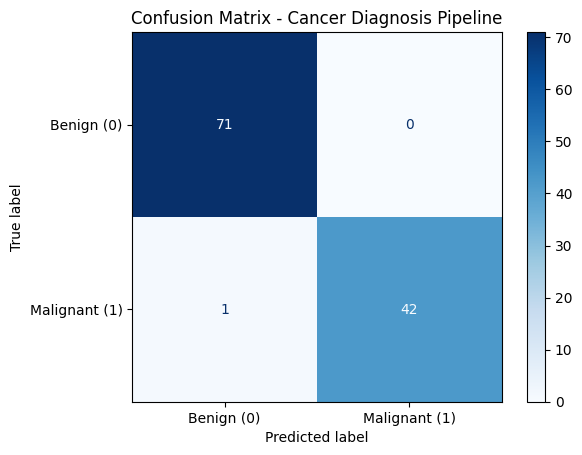

In [49]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)

# 1. Generate predictions on test data
ypred = pipe.predict(xtest)

# 2. Compute raw confusion matrix
cm = confusion_matrix(ytest, ypred)
print("Confusion Matrix:\n", cm)

# 3. Print detailed classification metrics (Precision, Recall, F1-score)
print("\nClassification Report:\n")
print(
    classification_report(
        ytest, ypred, target_names=["Benign (0)", "Malignant (1)"]
    )
)

# 4. Plot visual confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Benign (0)", "Malignant (1)"]
)
disp.plot(cmap=plt.cm.Blues, values_format="d")
plt.title("Confusion Matrix - Cancer Diagnosis Pipeline")
plt.grid(False)
plt.show()

In [50]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe, x, y, cv=cv, scoring='accuracy')

print(f"Mean CV Accuracy: {scores.mean() * 100:.2f}% (+/- {scores.std() * 100:.2f}%)")

Mean CV Accuracy: 97.37% (+/- 1.24%)
